<a href="https://colab.research.google.com/github/fehmidataj27-dotcom/desktop-tutorial/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib
import datetime


In [ ]:
# Cell 2: load data
df = pd.read_csv("energy_data.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# Cell 3: basic cleaning
# ensure uniform frequency (hourly)
df = df.set_index("timestamp").asfreq("H")  # or 'D' for daily
df['energy_kwh'] = df['energy_kwh'].interpolate(method='time')  # fill small gaps
# optional: forward/backfill large gaps and mark them


/tmp/ipython-input-2274121760.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.set_index("timestamp").asfreq("H")  # or 'D' for daily


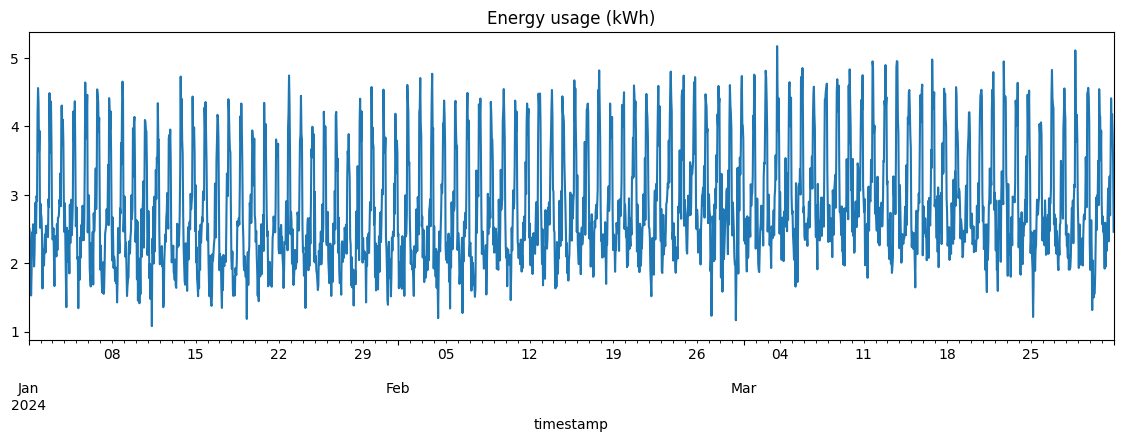

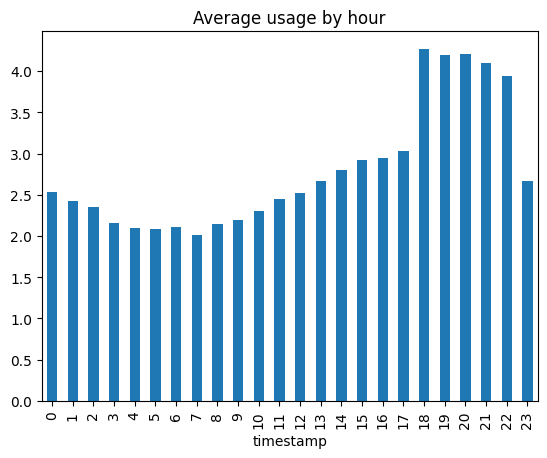

In [ ]:
# Cell 4: quick plots
df['energy_kwh'].plot(figsize=(14,4), title="Energy usage (kWh)")
plt.show()

# hourly profile
hourly = df.groupby(df.index.hour)['energy_kwh'].mean()
hourly.plot(kind='bar', title='Average usage by hour')
plt.show()


In [ ]:
# Cell 5: time features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['month'] = df.index.month
df['sin_hour'] = np.sin(2*np.pi*df['hour']/24)
df['cos_hour'] = np.cos(2*np.pi*df['hour']/24)

# lags & rolling windows
for lag in [1,2,24,48]:
    df[f'lag_{lag}'] = df['energy_kwh'].shift(lag)
for w in [3,6,24]:
    df[f'roll_mean_{w}'] = df['energy_kwh'].shift(1).rolling(w).mean()

# temperature features if available
if 'temperature' in df.columns:
    df['temp_lag1'] = df['temperature'].shift(1)


In [ ]:
# Cell 6: drop NA from lagging
df_model = df.dropna().copy()

# split last N days/hours as test
test_hours = 24*7  # last week as test (adjustable)
train = df_model.iloc[:-test_hours]
test = df_model.iloc[-test_hours:]

X_cols = [c for c in df_model.columns if c not in ['energy_kwh']]
X_train, y_train = train[X_cols], train['energy_kwh']
X_test, y_test = test[X_cols], test['energy_kwh']


In [ ]:
# Cell 7: persistence baseline
y_pred_persist = test['lag_1']  # naive: predict last hour
mae_persist = mean_absolute_error(y_test, y_pred_persist)
rmse_persist = np.sqrt(mean_squared_error(y_test, y_pred_persist))

# Linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("Baseline MAE", mae_persist, "LR MAE", mae_lr)

Baseline MAE 0.41466480334189065 LR MAE 0.2734675161012285


In [ ]:
# Cell 8: xgboost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
params = {"objective":"reg:squarederror", "learning_rate":0.1, "max_depth":6}
bst = xgb.train(params, dtrain, num_boost_round=200, evals=[(dtest,'test')], early_stopping_rounds=20)
y_pred_xgb = bst.predict(dtest)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print("XGBoost MAE", mae_xgb)

[0]	test-rmse:0.75070
[1]	test-rmse:0.69027
[2]	test-rmse:0.63483
[3]	test-rmse:0.58544
[4]	test-rmse:0.54293
[5]	test-rmse:0.50484
[6]	test-rmse:0.47248
[7]	test-rmse:0.44524
[8]	test-rmse:0.42058
[9]	test-rmse:0.40011
[10]	test-rmse:0.38411
[11]	test-rmse:0.37018
[12]	test-rmse:0.35735
[13]	test-rmse:0.34711
[14]	test-rmse:0.33792
[15]	test-rmse:0.33177
[16]	test-rmse:0.32583
[17]	test-rmse:0.32216
[18]	test-rmse:0.31830
[19]	test-rmse:0.31550
[20]	test-rmse:0.31251
[21]	test-rmse:0.31068
[22]	test-rmse:0.30843
[23]	test-rmse:0.30771
[24]	test-rmse:0.30744
[25]	test-rmse:0.30626
[26]	test-rmse:0.30643
[27]	test-rmse:0.30562
[28]	test-rmse:0.30477
[29]	test-rmse:0.30516
[30]	test-rmse:0.30520
[31]	test-rmse:0.30442
[32]	test-rmse:0.30517
[33]	test-rmse:0.30477
[34]	test-rmse:0.30468
[35]	test-rmse:0.30490
[36]	test-rmse:0.30506
[37]	test-rmse:0.30580
[38]	test-rmse:0.30600
[39]	test-rmse:0.30591
[40]	test-rmse:0.30642
[41]	test-rmse:0.30687
[42]	test-rmse:0.30634
[43]	test-rmse:0.3064

In [ ]:
# Cell 9: LSTM data prep (example: use last 48 hours to predict next hour)
from sklearn.preprocessing import MinMaxScaler
seq_len = 48
cols = ['energy_kwh','temperature','sin_hour','cos_hour']  # adjust

scaler = MinMaxScaler()
arr = scaler.fit_transform(df_model[cols])
X_seq, y_seq = [], []
for i in range(seq_len, len(arr)):
    X_seq.append(arr[i-seq_len:i])
    y_seq.append(arr[i, 0])  # energy_kwh is first column
X_seq = np.array(X_seq); y_seq = np.array(y_seq)

# split by time
split_idx = len(X_seq) - test_hours
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

# build model
model = models.Sequential([
    layers.Input(shape=(seq_len, X_seq.shape[2])),
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_seq, y_train_seq, validation_data=(X_test_seq,y_test_seq), epochs=20, batch_size=32)

# predictions (rescale)
y_pred_lstm_scaled = model.predict(X_test_seq).flatten()
# inverse transform: only energy_kwh scaling — careful reconstruct vector for inverse scaling


Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0946 - val_loss: 0.0129
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0130 - val_loss: 0.0112
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0104 - val_loss: 0.0095
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0086 - val_loss: 0.0102
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_loss: 0.0081
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - val_loss: 0.0093
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0082 - val_loss: 0.0094
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 0.0072
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0075 - val_loss: 0.0083
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val

In [ ]:
# Cell 10: summary table
results = {
    'persistence':[mae_persist, rmse_persist],
    'linear_regression':[mae_lr, rmse_lr],
    'xgboost':[mae_xgb, rmse_xgb],
    # 'lstm':[mae_lstm, rmse_lstm]
}
res_df = pd.DataFrame(results, index=['MAE','RMSE']).T
print(res_df)


                        MAE      RMSE
persistence        0.414665  0.561065
linear_regression  0.273468  0.342998
xgboost            0.248889  0.305195


In [ ]:
# Cell 11: simple scheduler
# Inputs: predicted baseline by hour for next 24h (pred24), appliance_kwh, duration_hours, allowed_window (start,end), tariff array (24)
# brute-force approach: evaluate all possible start times within allowed window and pick min cost

def best_start(pred24, appliance_kwh_per_hour, duration, allowed_hours, tariff):
    best = None
    for start in allowed_hours:
        hours = [(start + i) % 24 for i in range(duration)]
        added_load = np.zeros(24)
        for h in hours:
            added_load[h] += appliance_kwh_per_hour
        total_cost = np.sum((pred24 + added_load) * tariff)
        if best is None or total_cost < best[0]:
            best = (total_cost, start, hours)
    return best


In [ ]:
# demo_predict_schedule.py
import joblib, numpy as np, pandas as pd
import os
import xgboost as xgb

# Create the models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save the trained model and scaler
joblib.dump(bst, 'models/xgb_model.byt')
joblib.dump(scaler, 'models/scaler.byt')

# load
xgb_model = joblib.load('models/xgb_model.byt')
scaler = joblib.load('models/scaler.byt')

# assume we have next24_preds from model
# We need to create X_next24 based on the last `seq_len` observations from the original data, and then add future time features.
# For a simple demo, let's create a placeholder X_next24.
# In a real scenario, this would involve forecasting future features or having them available.

# For demonstration, let's take the last 24 hours from the test set and assume they are 'next24_preds' features
# This is a simplification and would need actual future data/forecasts in a real application.
last_test_hour = X_test.iloc[-1].name # Get the timestamp of the last hour in X_test
future_timestamps = pd.date_range(start=last_test_hour + pd.Timedelta(hours=1), periods=24, freq='h')

# Create a DataFrame for X_next24 with appropriate columns and dummy values for demonstration
X_next24 = pd.DataFrame(0, index=future_timestamps, columns=X_cols)

# Populate time-based features for X_next24
X_next24['hour'] = X_next24.index.hour
X_next24['dayofweek'] = X_next24.index.dayofweek
X_next24['is_weekend'] = X_next24['dayofweek'].isin([5,6]).astype(int)
X_next24['month'] = X_next24.index.month
X_next24['sin_hour'] = np.sin(2*np.pi*X_next24['hour']/24)
X_next24['cos_hour'] = np.cos(2*np.pi*X_next24['hour']/24)

# For other features like 'temperature', 'lag_x', 'roll_mean_x', 'temp_lag1',
# a more robust forecasting or external data source would be needed.
# For this demo, we'll fill them with simple placeholder values or 0.
# In a real scenario, you'd forecast these values or derive them from recent observations.

# Example: filling 'temperature' with a hypothetical average or last known value
X_next24['temperature'] = df_model['temperature'].mean() # or df_model['temperature'].iloc[-1]
X_next24['temp_lag1'] = X_next24['temperature'].shift(1).fillna(df_model['temperature'].iloc[-1]) # or fill with mean

# Fill lag features based on the end of the df_model or with zeros for simplicity in this demo
for lag_col in [c for c in X_cols if 'lag_' in c or 'roll_mean_' in c]:
    X_next24[lag_col] = 0.0 # Placeholder: in reality, this would be based on actual lagged values of energy_kwh

d_X_next24 = xgb.DMatrix(X_next24)
pred24 = xgb_model.predict(d_X_next24)  # implement X_next24 creation

# example tariff (24 hours)
tariff = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.2, 0.3, 0.3, 0.3, 0.2, 0.2, 0.2, 0.3, 0.4, 0.4, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])  # $/kWh for each hour

# schedule washer: 1.0 kWh/hr, duration=2, allowed 6am-10pm
appliance_kwh = 1.0
duration = 2
allowed_hours = list(range(6,22))
best = best_start(pred24, appliance_kwh, duration, allowed_hours, tariff)
print(f"Recommend start hour: {best[1]}, estimated extra cost: {best[0]}")

Recommend start hour: 18, estimated extra cost: 12.352144598960876
